Loading MNIST...
Dataset shape : (70000, 784)
Label : 5


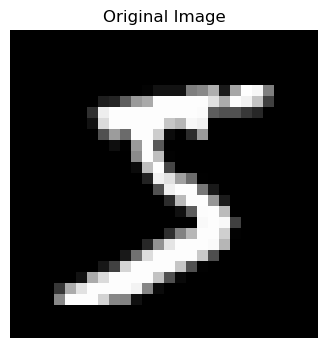

In [1]:
# =====================================
# TP PCA - Image Compression (MNIST)
# =====================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

print("Loading MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset shape :", X.shape)

# Normalize pixels

X = X / 255.0

# Select one image

image = X[0]

print("Label :", y[0])

plt.figure(figsize=(4,4))
plt.imshow(image.reshape(28,28), cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [2]:
# =====================================
# Train PCA on the whole MNIST dataset
# =====================================

n_components = 50

pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X)

print("Original dimension :", X.shape[1])
print("Reduced dimension  :", X_pca.shape[1])

print("Compression ratio : {:.2f}%".format(
    100 * n_components / X.shape[1]
))

Original dimension : 784
Reduced dimension  : 50
Compression ratio : 6.38%


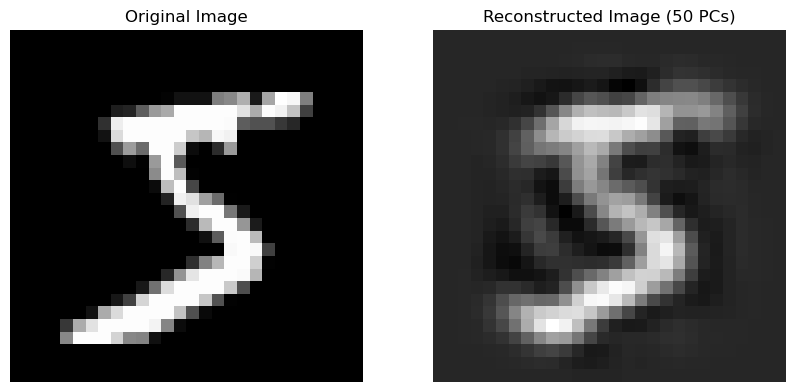

In [3]:
# =====================================
# Reconstruct image using inverse PCA
# =====================================

# Reconstruct all images
X_reconstructed = pca.inverse_transform(X_pca)

# Select the first reconstructed image
reconstructed_image = X_reconstructed[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image.reshape(28,28), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed_image.reshape(28,28), cmap="gray")
plt.title("Reconstructed Image (50 PCs)")
plt.axis("off")

plt.show()

Components for 90% variance : 87
Components for 95% variance : 154


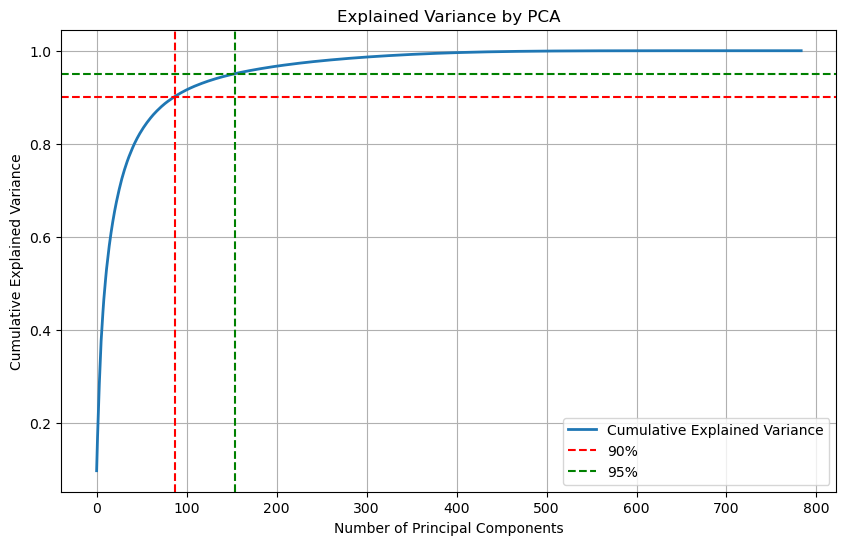

In [4]:
# =====================================
# Explained Variance
# =====================================

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# PCA with all possible components
pca_full = PCA()

pca_full.fit(X)

# Explained variance
explained_variance = pca_full.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Number of components for 90% and 95%
n90 = np.argmax(cumulative_variance >= 0.90) + 1
n95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Components for 90% variance : {n90}")
print(f"Components for 95% variance : {n95}")

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    cumulative_variance,
    linewidth=2,
    label="Cumulative Explained Variance"
)

plt.axhline(
    y=0.90,
    color='red',
    linestyle='--',
    label='90%'
)

plt.axhline(
    y=0.95,
    color='green',
    linestyle='--',
    label='95%'
)

plt.axvline(
    x=n90,
    color='red',
    linestyle='--'
)

plt.axvline(
    x=n95,
    color='green',
    linestyle='--'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")

plt.grid(True)

plt.legend()

plt.show()

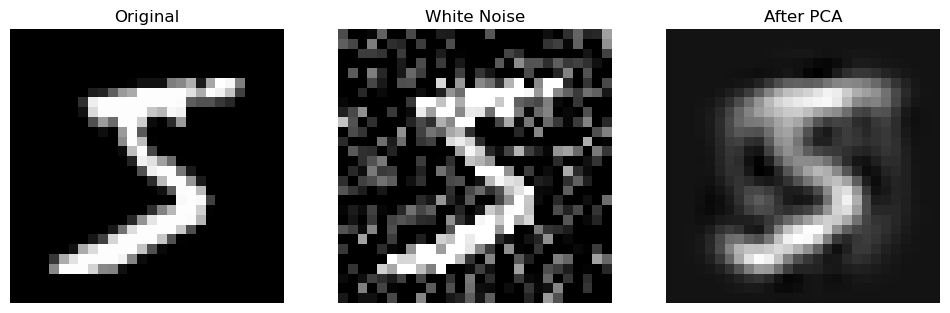

In [5]:
# =====================================
# Noise Reduction using PCA
# =====================================

import numpy as np
import matplotlib.pyplot as plt

# Original image
original = X[0].reshape(28,28)

# Add white noise
noise = np.random.normal(0,0.30,(28,28))
noisy = original + noise
noisy = np.clip(noisy,0,1)

# Transform noisy image
noisy_vector = noisy.reshape(1,-1)

compressed = pca.transform(noisy_vector)

denoised = pca.inverse_transform(compressed)

denoised = denoised.reshape(28,28)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(original,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy,cmap='gray')
plt.title("White Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(denoised,cmap='gray')
plt.title("After PCA")
plt.axis("off")

plt.show()